In [15]:
import pandas as pd

In [16]:
df_exoplanet = pd.read_csv('cumulative.csv')


In [17]:
df_exoplanet.columns

Index(['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='str')

In [18]:
df_exoplanet.shape

(9564, 50)

In [19]:
df_exoplanet.head(10)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
5,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
6,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
7,8,10872983,K00756.03,Kepler-228 b,CONFIRMED,CANDIDATE,0.992,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
8,9,6721123,K00114.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-124.0,3.986,0.182,-0.098,1.958,0.322,-0.483,298.86435,42.151569,12.660
9,10,10910878,K00757.01,Kepler-229 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-83.0,4.485,0.083,-0.028,0.848,0.033,-0.072,286.99948,48.375790,15.841


In [20]:
# പ്രധാനപ്പെട്ട കോളങ്ങൾ മാത്രം തിരഞ്ഞെടുക്കുന്നു
selected_columns = [
    'rowid',            # id column
    'kepler_name',      # ഗ്രഹത്തിന്റെ പേര്
    'koi_disposition',  # നാസയുടെ കൺഫേംഡ് സ്റ്റാറ്റസ്
    'koi_period',       # ഒരു തവണ വലംവെക്കാൻ എടുക്കുന്ന സമയം (Days)
    'koi_prad',         # ഗ്രഹത്തിന്റെ വലിപ്പം (Planet Radius - Earth radius-ൽ)
    'koi_teq',          # ഗ്രഹത്തിലെ താപനില (Equilibrium Temperature - Kelvin-ൽ)
    'koi_insol',        # ലഭിക്കുന്ന പ്രകാശത്തിന്റെ അളവ് (Stellar Flux)
    'koi_score',        # കെപ്ലർ ഒബ്ജക്റ്റ് ആകാനുള്ള സാധ്യത സ്കോർ
    'koi_kepmag'        # ആ എക്സോപ്ലാനറ്റ് (ഗ്രഹം) വലംവെക്കുന്ന നക്ഷത്രത്തിന്റെ തിളക്കം (Brightness) അളക്കുന്ന യൂണിറ്റാണിത്
]

# പുതിയ ഡാറ്റാഫ്രെയിം ഉണ്ടാക്കുന്നു
df_filtered = df_exoplanet[selected_columns]

# പുതിയ ഡാറ്റയുടെ വിവരങ്ങൾ നോക്കാൻ
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rowid            9564 non-null   int64  
 1   kepler_name      2294 non-null   str    
 2   koi_disposition  9564 non-null   str    
 3   koi_period       9564 non-null   float64
 4   koi_prad         9201 non-null   float64
 5   koi_teq          9201 non-null   float64
 6   koi_insol        9243 non-null   float64
 7   koi_score        8054 non-null   float64
 8   koi_kepmag       9563 non-null   float64
dtypes: float64(6), int64(1), str(2)
memory usage: 809.7 KB


In [21]:
df_location = df_exoplanet[['rowid', 'dec', 'ra']]
df_location.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rowid   9564 non-null   int64  
 1   dec     9564 non-null   float64
 2   ra      9564 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 224.3 KB


In [22]:
# 1. ആദ്യം ജീവൻ നിലനിൽക്കാൻ സാധ്യതയുള്ള ഗ്രഹങ്ങളെ മാത്രം കണ്ടെത്താനുള്ള കണ്ടീഷൻ വെക്കുന്നു
# താപനില (180K - 310K) ആൻഡ് ഗ്രഹത്തിന്റെ വലിപ്പം (0.5 - 2.5 Earth radius)
habitable_condition = (df_exoplanet['koi_teq'] >= 180) & (df_exoplanet['koi_teq'] <= 310) & \
                     (df_exoplanet['koi_prad'] >= 0.5) & (df_exoplanet['koi_prad'] <= 2.5)

# ഈ കണ്ടീഷൻ സാറ്റിസ്ഫൈ ചെയ്യുന്ന ഗ്രഹങ്ങൾ മാത്രം ഉള്ള ഒരു മാസ്റ്റർ ടേബിൾ
df_habitable_master = df_exoplanet[habitable_condition]

# 2. ടേബിൾ 1: ജീവിക്കാൻ സാധ്യതയുള്ള ഗ്രഹങ്ങളുടെ ഫിസിക്കൽ വിവരങ്ങൾ (rowid സഹിതം)
df_habitable = df_habitable_master[['rowid', 'kepler_name', 'koi_period', 'koi_prad', 'koi_teq', 'koi_insol']]

# 3. ടേബിൾ 2: ആ ഗ്രഹങ്ങളുടെ ലൊക്കേഷൻ വിവരങ്ങൾ മാത്രം (rowid സഹിതം)
df_location = df_habitable_master[['rowid', 'dec', 'ra']]

# ഫിൽട്ടർ ചെയ്ത ശേഷം എത്ര ഗ്രഹങ്ങൾ ഉണ്ടെന്ന് നോക്കാൻ
print("Habitable planet count:", df_habitable.shape[0])

Habitable planet count: 461


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# ഗ്രാഫുകൾ നല്ല ക്വാളിറ്റിയിൽ വരാൻ വേണ്ടി ഒരു സ്റ്റൈൽ സെറ്റ് ചെയ്യുന്നു
sns.set_theme(style="darkgrid")

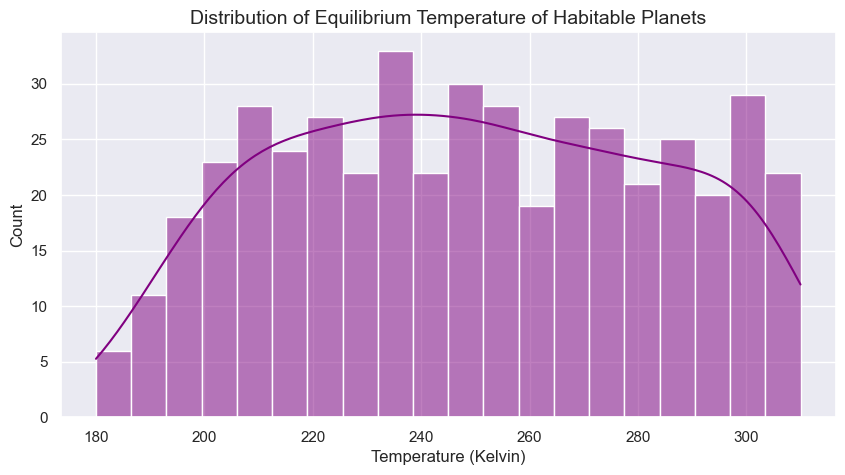

In [25]:
# looking tempreture destribution graph

plt.figure(figsize=(10, 5))
sns.histplot(df_habitable['koi_teq'], bins=20, kde=True, color='purple')
plt.title('Distribution of Equilibrium Temperature of Habitable Planets', fontsize=14)
plt.xlabel('Temperature (Kelvin)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

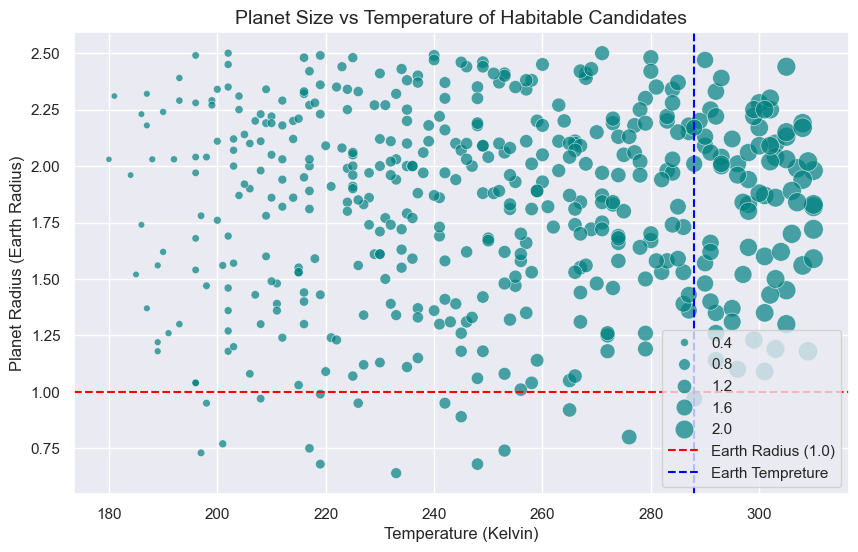

In [26]:
# looking for tempreture&size of planets

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_habitable, x='koi_teq', y='koi_prad', size='koi_insol', sizes=(20, 200), alpha=0.7, color='teal')
plt.axhline(1.0, color='red', linestyle='--', label='Earth Radius (1.0)') # ഭൂമിയുടെ വലിപ്പം കാണിക്കുന്ന ലൈൻ
plt.axvline(288, color='blue', linestyle='--', label='Earth Tempreture')
plt.title('Planet Size vs Temperature of Habitable Candidates', fontsize=14)
plt.xlabel('Temperature (Kelvin)', fontsize=12)
plt.ylabel('Planet Radius (Earth Radius)', fontsize=12)
plt.legend()
plt.show()

In [27]:
# ഫിൽറ്റർ ചെയ്ത രണ്ട് ടേബിളുകളെ പുതിയ സി.എസ്.വി ഫയലുകളാക്കി മാറ്റുന്നു
df_habitable.to_csv('habitable_planets.csv', index=False)
df_location.to_csv('planet_locations.csv', index=False)

print("The tow table saved succesfully! 👍")

The tow table saved succesfully! 👍
